# Sistema dinamico de recomendacion basado en likes simulados

Este notebook reutiliza los embeddings generados previamente para estudiar unicamente la capa de comportamiento del usuario. La idea es simular likes, construir perfiles vectoriales a partir de ellos y observar como cambian las recomendaciones sin reentrenar el modelo base.

El objetivo en esta version es hacer la evaluacion mas exigente y analiticamente interesante. Para ello se mantienen los mismos embeddings y la misma arquitectura general, pero se incorporan metricas adicionales, ruido controlado y una comparacion entre media simple y ponderacion temporal.

In [33]:
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

ARTIFACTS_PATH = Path("artifacts/embeddings_posts.joblib")
CLASSIFIER_PATH = Path("models/clasificador_embeddings.joblib")
DATA_PATH = Path("data/posts.csv")

TOP_K = 5
TOP_K_DIVERSIDAD = 10
ETAPAS = [3, 5, 8]
ALPHA_RECIENTE = 0.7

pd.set_option("display.max_colwidth", 120)

## 1. Carga de artefactos reutilizables

La ruta principal intenta reutilizar directamente el artefacto persistido. Si el archivo serializado no es compatible con la version local de `pandas`, el notebook aplica un fallback controlado: reconstruye `df_modelo` desde `posts.csv` y regenera los embeddings con el mismo encoder original, pero sin descargar nada de internet.

In [34]:
required_columns = {"texto_limpio", "categoria"}

try:
    artefacto = joblib.load(ARTIFACTS_PATH)
    required_keys = {"embeddings", "posts"}
    if not required_keys.issubset(artefacto):
        raise ValueError(
            f"El artefacto debe contener las claves {required_keys}. Claves disponibles: {sorted(artefacto.keys())}"
        )

    embeddings_posts = np.asarray(artefacto["embeddings"], dtype=np.float32)
    df_modelo = artefacto["posts"].copy().reset_index(drop=True)
    embedding_model_name = artefacto.get("embedding_model_name", "desconocido")
    origen_carga = "artefacto persistido"
except Exception as exc:
    metadata_clasificador = joblib.load(CLASSIFIER_PATH)
    embedding_model_name = metadata_clasificador.get(
        "embedding_model_name",
        "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    )

    df = pd.read_csv(DATA_PATH, encoding="utf-8")
    df = df[["id", "descripcion", "hashtags", "categoria"]].copy()
    df["texto_original"] = (
        df["descripcion"].fillna("").astype(str).str.strip()
        + " "
        + df["hashtags"].fillna("").astype(str).str.strip()
    ).str.replace(r"\s+", " ", regex=True).str.strip()

    def preprocesar_texto(texto):
        texto = str(texto).lower()
        texto = texto.replace("#", " ")
        texto = re.sub(r"[^a-zA-Z0-9\sáéíóúüñ]", " ", texto)
        texto = re.sub(r"\s+", " ", texto).strip()
        return texto

    df["texto_limpio"] = df["texto_original"].apply(preprocesar_texto)
    df_modelo = df[df["texto_limpio"].str.len() > 0].copy().reset_index(drop=True)

    try:
        from sentence_transformers import SentenceTransformer
    except ImportError as import_exc:
        raise ImportError(
            "No se pudo leer el artefacto serializado y tampoco esta disponible sentence-transformers para regenerar embeddings."
        ) from import_exc

    modelo_embeddings = SentenceTransformer(embedding_model_name, local_files_only=True)
    embeddings_posts = modelo_embeddings.encode(
        df_modelo["texto_limpio"].tolist(),
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
    )
    origen_carga = f"fallback activado por incompatibilidad del artefacto: {exc.__class__.__name__}"

if not required_columns.issubset(df_modelo.columns):
    raise ValueError(
        f"df_modelo debe incluir las columnas {required_columns}. Columnas disponibles: {df_modelo.columns.tolist()}"
    )

if len(df_modelo) != len(embeddings_posts):
    raise ValueError(
        "El numero de filas de df_modelo no coincide con el numero de embeddings. "
        f"Filas: {len(df_modelo)} | Embeddings: {len(embeddings_posts)}"
    )

df_modelo["texto"] = df_modelo["texto_limpio"]

print(f"Origen de carga: {origen_carga}")
print(f"Modelo de embeddings: {embedding_model_name}")
print(f"Matriz de embeddings: {embeddings_posts.shape[0]} posts x {embeddings_posts.shape[1]} dimensiones")
display(df_modelo[["categoria", "texto"]].head())

Origen de carga: artefacto persistido
Modelo de embeddings: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Matriz de embeddings: 4931 posts x 384 dimensiones


,categoria,texto
0,musica,temazo descubriendo joyitas indies en spotify increible acustico indie
1,animales,este gato callejero ya es prácticamente mío qué bonitos son lol amoranimal doglife naturaleza veterinario
2,animales,literalmente el mejor momento del día este gato callejero ya es prácticamente mío
3,viajes,perdidos por cádiz perdido en el metro de república dominicana ayuda explorando
4,viajes,próxima parada pagando un café a precio de turista paisaje naturaleza mochileros roadtrip travel


## 2. Utilidades de simulacion y evaluacion

Se mantienen operaciones sencillas sobre el espacio vectorial, pero la evaluacion deja de considerar como relevante cualquier post de una categoria objetivo. Para evitar una `Precision@5` trivialmente perfecta, se define un **pool de relevancia estricto**: un subconjunto de posts semanticamente cercanos al perfil objetivo, obtenido dentro de las categorias relevantes.

Esto hace que la precision mida recuperacion de items realmente proximos al interes simulado, no solo coincidencia de categoria.

In [35]:
def normalizar_vector(vector):
    vector = np.asarray(vector, dtype=np.float32)
    if vector.ndim == 1:
        vector = vector.reshape(1, -1)

    norma = np.linalg.norm(vector, axis=1, keepdims=True)
    norma[norma == 0] = 1.0
    return vector / norma


def construir_perfil_media(indices_likeados):
    perfil = embeddings_posts[indices_likeados].mean(axis=0, keepdims=True)
    return normalizar_vector(perfil)


def actualizar_perfil_media(perfil_actual, nuevo_embedding, n_likes_previos):
    # Media incremental clasica: cada nuevo like pesa 1 / (t + 1).
    nuevo_perfil = (perfil_actual * n_likes_previos + nuevo_embedding.reshape(1, -1)) / (n_likes_previos + 1)
    return normalizar_vector(nuevo_perfil)


def actualizar_perfil_ponderado(perfil_actual, nuevo_embedding, alpha=ALPHA_RECIENTE):
    # Ponderacion temporal simple: el embedding mas reciente domina la actualizacion.
    nuevo_perfil = alpha * nuevo_embedding.reshape(1, -1) + (1 - alpha) * perfil_actual
    return normalizar_vector(nuevo_perfil)


def recomendar_posts(perfil_usuario, indices_excluidos, top_k=TOP_K):
    similitudes = cosine_similarity(perfil_usuario, embeddings_posts).ravel()
    mascara = np.ones(len(df_modelo), dtype=bool)
    mascara[list(indices_excluidos)] = False

    recomendaciones = df_modelo.loc[mascara, ["texto", "categoria"]].copy()
    recomendaciones["score_similitud"] = similitudes[mascara]
    recomendaciones["indice"] = np.flatnonzero(mascara)
    recomendaciones = recomendaciones.sort_values("score_similitud", ascending=False).head(top_k).copy()
    return recomendaciones.reset_index(drop=True)


def precision_at_k(recomendaciones, pool_relevante):
    return recomendaciones["indice"].isin(pool_relevante).mean()


def cobertura_objetivo_at_k(recomendaciones, categorias_objetivo):
    return recomendaciones["categoria"].isin(categorias_objetivo).mean()


def diversidad_at_k(recomendaciones):
    return recomendaciones["categoria"].nunique()


def estabilidad_ranking(top_a, top_b):
    return len(set(top_a["indice"]).intersection(set(top_b["indice"]))) / len(top_a)


def distancia_perfiles(perfil_a, perfil_b):
    return float(np.linalg.norm(perfil_a - perfil_b))


def primer_indice_disponible(categoria, usados):
    candidatos = df_modelo.index[df_modelo["categoria"].eq(categoria)].tolist()
    for indice in candidatos:
        if indice not in usados:
            return int(indice)
    raise ValueError(f"No quedan posts disponibles para la categoria: {categoria}")


def construir_pool_relevante_estricto(categorias_objetivo, categorias_semilla, holdout_por_categoria=5, top_m=25):
    usados = set()
    indices_semilla = []

    for categoria in categorias_semilla:
        indice = primer_indice_disponible(categoria, usados)
        indices_semilla.append(indice)
        usados.add(indice)

    indices_oraculo = indices_semilla.copy()
    usados_oraculo = set(indices_semilla)

    for categoria in categorias_objetivo:
        candidatos = [
            indice
            for indice in df_modelo.index[df_modelo["categoria"].eq(categoria)].tolist()
            if indice not in usados_oraculo
        ]

        perfil_categoria = normalizar_vector(embeddings_posts[candidatos].mean(axis=0, keepdims=True))
        similitudes = cosine_similarity(perfil_categoria, embeddings_posts[candidatos]).ravel()

        prototipos = (
            pd.DataFrame({"indice": candidatos, "similitud": similitudes})
            .sort_values("similitud", ascending=False)
            .head(holdout_por_categoria)
        )

        nuevos_indices = prototipos["indice"].tolist()
        indices_oraculo.extend(nuevos_indices)
        usados_oraculo.update(nuevos_indices)

    perfil_oraculo = normalizar_vector(embeddings_posts[indices_oraculo].mean(axis=0, keepdims=True))
    candidatas = recomendar_posts(perfil_oraculo, set(indices_semilla), top_k=120)

    pool_relevante = set(
        candidatas[candidatas["categoria"].isin(categorias_objetivo)]
        .head(top_m)["indice"]
        .tolist()
    )
    return indices_semilla, pool_relevante


def simular_usuario(categorias_iniciales, categorias_objetivo, estrategia="media", alpha=ALPHA_RECIENTE, etapas=ETAPAS):
    categorias_objetivo = set(categorias_objetivo)
    indices_iniciales, pool_relevante = construir_pool_relevante_estricto(
        categorias_objetivo,
        categorias_iniciales,
    )

    historial = indices_iniciales.copy()
    perfil = construir_perfil_media(historial)

    snapshots = {
        3: {
            "historial": historial.copy(),
            "perfil": perfil.copy(),
            "top5": recomendar_posts(perfil, historial, top_k=TOP_K),
            "top_diversidad": recomendar_posts(perfil, historial, top_k=TOP_K_DIVERSIDAD),
        }
    }

    while len(historial) < max(etapas):
        candidatas = recomendar_posts(perfil, historial, top_k=30)
        coincidencias = candidatas[candidatas["categoria"].isin(categorias_objetivo)]
        fila_like = coincidencias.iloc[0] if not coincidencias.empty else candidatas.iloc[0]
        indice_like = int(fila_like["indice"])

        if estrategia == "media":
            perfil = actualizar_perfil_media(perfil, embeddings_posts[indice_like], len(historial))
        elif estrategia == "ponderado":
            perfil = actualizar_perfil_ponderado(perfil, embeddings_posts[indice_like], alpha=alpha)
        else:
            raise ValueError("La estrategia debe ser 'media' o 'ponderado'.")

        historial.append(indice_like)

        if len(historial) in etapas:
            snapshots[len(historial)] = {
                "historial": historial.copy(),
                "perfil": perfil.copy(),
                "top5": recomendar_posts(perfil, historial, top_k=TOP_K),
                "top_diversidad": recomendar_posts(perfil, historial, top_k=TOP_K_DIVERSIDAD),
            }

    filas_metricas = []
    for etapa in etapas:
        top5 = snapshots[etapa]["top5"].copy()
        top_diversidad = snapshots[etapa]["top_diversidad"].copy()

        filas_metricas.append(
            {
                "n_likes": etapa,
                "precision_at_5": round(precision_at_k(top5, pool_relevante), 2),
                "cobertura_objetivo_at_5": round(cobertura_objetivo_at_k(top5, categorias_objetivo), 2),
                "diversidad_at_10": diversidad_at_k(top_diversidad),
                "score_medio_top5": round(float(top5["score_similitud"].mean()), 4),
                "categorias_top5": " | ".join(top5["categoria"].tolist()),
            }
        )

    df_metricas = pd.DataFrame(filas_metricas)
    top5_3 = snapshots[3]["top5"]
    top5_8 = snapshots[8]["top5"]
    perfil_3 = snapshots[3]["perfil"]
    perfil_8 = snapshots[8]["perfil"]

    resumen = {
        "estrategia": estrategia,
        "categorias_iniciales": categorias_iniciales,
        "categorias_objetivo": categorias_objetivo,
        "overlap_top5_3_8": round(estabilidad_ranking(top5_3, top5_8), 2),
        "distancia_perfiles_3_8": round(distancia_perfiles(perfil_3, perfil_8), 4),
        "pool_relevante_size": len(pool_relevante),
    }

    return {
        "likes_iniciales": df_modelo.loc[indices_iniciales, ["categoria", "texto"]].copy().reset_index(drop=True),
        "pool_relevante": pool_relevante,
        "metricas": df_metricas,
        "snapshots": snapshots,
        "resumen": resumen,
    }

## 3. Simulacion principal: usuario multiinteres

Se simula un usuario con tres intereses iniciales: `animales`, `coches` y `playa`. Este caso es util porque no parte de una unica categoria dominante, lo que permite observar como el ranking puede concentrarse progresivamente en una region concreta del espacio semantico.

In [36]:
resultado_principal = simular_usuario(
    categorias_iniciales=["animales", "coches", "playa"],
    categorias_objetivo={"animales", "coches", "playa"},
    estrategia="media",
)

print("Likes iniciales del usuario multiinteres:")
display(resultado_principal["likes_iniciales"])

print("Top-5 despues de 3 likes:")
display(resultado_principal["snapshots"][3]["top5"][["texto", "categoria", "score_similitud"]])

print("Top-5 despues de 8 likes:")
display(resultado_principal["snapshots"][8]["top5"][["texto", "categoria", "score_similitud"]])

Likes iniciales del usuario multiinteres:


,categoria,texto
0,animales,este gato callejero ya es prácticamente mío qué bonitos son lol amoranimal doglife naturaleza veterinario
1,coches,brum brum la gasolina a precio de oooooro pero sigo dandole cana me encanta carporn tuning llantas exhaust v8
2,playa,por fin postureo máximo en la orilla con emelina y no necesito más costa olas paraiso brisa


Top-5 despues de 3 likes:


,texto,categoria,score_similitud
0,enamorado de este bicho derrape guapo en la última rotonda me encanta v6 motorsport turbo carporn,coches,0.737905
1,enamorado de este bicho la gasolina a precio de oro pero sigo dandole cana lol exhaust caballos carporn v6 cochescla...,coches,0.705936
2,enamorado de este bicho cambiando aceite y llantas ahora si impone gasss carporn ruta v8,coches,0.691966
3,enamorado de este bicho el motor v8 rugiendo como una bestia me encanta motor tuning carporn,coches,0.691118
4,enamorado de este bicho derrape guapo en la ultima rotonda puro vicio mecanica v8,coches,0.690229


Top-5 despues de 8 likes:


,texto,categoria,score_similitud
0,enamorado de este bicho el motor v8 rugiendo como una bestia velocidad motorsport motor v8,coches,0.873149
1,enamorado de este bicho el motor v8 rugiendo como una bestia exhaust mecanica tuning,coches,0.868667
2,enamorado de este bicho pasando la itv de puro milagro ruta motorsport v6 turbo cars,coches,0.863382
3,enamorado de este bicho interior de cueeeeero espectacular gasss v8 drive cochesclasicos,coches,0.848308
4,enamorado de este bicho el motor v8 rugiendo como una bestia gasss jajaja drive mecanica racing gas caballos,coches,0.847888


En esta version, `Precision@5` ya no significa solo "cuantos posts pertenecen a las categorias objetivo", sino "cuantos posts del top-5 caen dentro de un pool de relevancia semantica estricto". Por eso puede bajar aunque la cobertura por categoria siga siendo alta.

El `score_medio_top5` resume el nivel de similitud del ranking. Si aumenta con mas likes, el sistema esta concentrando las recomendaciones en una zona mas compacta del espacio semantico. Sin embargo, un score alto no garantiza diversidad: el ranking puede ser muy coherente pero tambien muy repetitivo.

,n_likes,precision_at_5,cobertura_objetivo_at_5,diversidad_at_10,score_medio_top5,categorias_top5
0,3,0.8,1.0,1,0.7034,coches | coches | coches | coches | coches
1,5,1.0,1.0,1,0.7896,coches | coches | coches | coches | coches
2,8,0.4,1.0,1,0.8603,coches | coches | coches | coches | coches


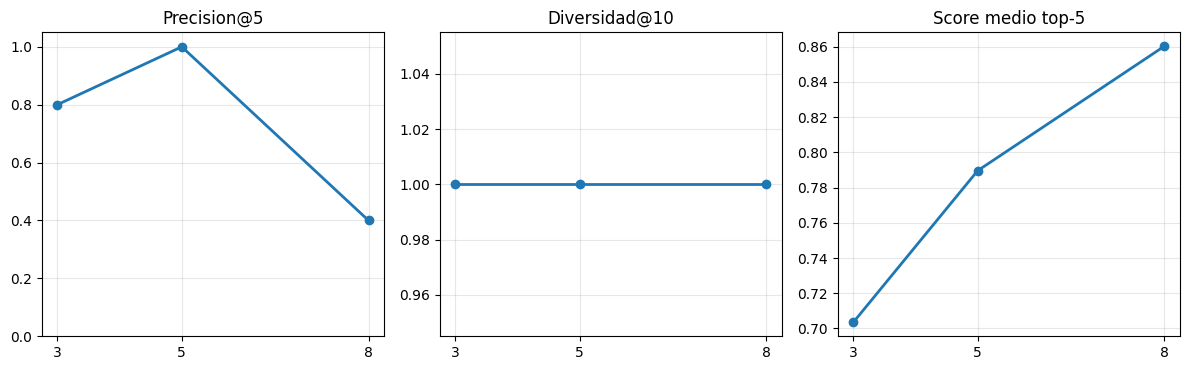

Pool relevante estricto: 25 posts
Estabilidad del ranking top-5 (3 likes vs 8 likes): 0.00
Distancia L2 entre perfiles (3 likes vs 8 likes): 0.4693


In [37]:
df_metricas_principal = resultado_principal["metricas"].copy()
display(df_metricas_principal)

plt.figure(figsize=(12, 3.8))

plt.subplot(1, 3, 1)
plt.plot(df_metricas_principal["n_likes"], df_metricas_principal["precision_at_5"], marker="o", linewidth=2)
plt.ylim(0, 1.05)
plt.xticks(df_metricas_principal["n_likes"])
plt.title("Precision@5")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(df_metricas_principal["n_likes"], df_metricas_principal["diversidad_at_10"], marker="o", linewidth=2)
plt.xticks(df_metricas_principal["n_likes"])
plt.title("Diversidad@10")
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(df_metricas_principal["n_likes"], df_metricas_principal["score_medio_top5"], marker="o", linewidth=2)
plt.xticks(df_metricas_principal["n_likes"])
plt.title("Score medio top-5")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Pool relevante estricto: {resultado_principal['resumen']['pool_relevante_size']} posts")
print(f"Estabilidad del ranking top-5 (3 likes vs 8 likes): {resultado_principal['resumen']['overlap_top5_3_8']:.2f}")
print(f"Distancia L2 entre perfiles (3 likes vs 8 likes): {resultado_principal['resumen']['distancia_perfiles_3_8']:.4f}")

Una `Diversidad@10` baja indica que el sistema esta explotando una zona semantica muy estrecha y devuelve pocas categorias distintas. Una diversidad alta sugiere que el perfil aun no se ha concentrado o que el historial mezcla intereses heterogeneos.

Una estabilidad alta significa que el ranking cambia poco entre dos momentos del historial; una estabilidad baja indica reordenaciones fuertes y, por tanto, sensibilidad a nuevas interacciones. La distancia L2 entre perfiles complementa esta lectura: cuanto mayor sea, mas se ha desplazado el usuario dentro del espacio de embeddings.

## 4. Ruido controlado en los likes

Ahora se compara un usuario puro de `playa` con un usuario casi puro, pero con un like ruidoso en `cocina`: `playa | playa | cocina`. La pregunta es si el sistema mantiene el foco en `playa` o si ese ruido inicial altera el ranking de forma relevante.

In [38]:
resultado_playa_puro = simular_usuario(
    categorias_iniciales=["playa", "playa", "playa"],
    categorias_objetivo={"playa"},
    estrategia="media",
)

resultado_playa_ruido = simular_usuario(
    categorias_iniciales=["playa", "playa", "cocina"],
    categorias_objetivo={"playa"},
    estrategia="media",
)

df_ruido = pd.DataFrame(
    [
        {
            "escenario": "playa | playa | playa",
            "precision_3_likes": resultado_playa_puro["metricas"].loc[0, "precision_at_5"],
            "precision_8_likes": resultado_playa_puro["metricas"].loc[2, "precision_at_5"],
            "diversidad_3_likes": resultado_playa_puro["metricas"].loc[0, "diversidad_at_10"],
            "diversidad_8_likes": resultado_playa_puro["metricas"].loc[2, "diversidad_at_10"],
            "score_3_likes": resultado_playa_puro["metricas"].loc[0, "score_medio_top5"],
            "score_8_likes": resultado_playa_puro["metricas"].loc[2, "score_medio_top5"],
            "overlap_top5_3_8": resultado_playa_puro["resumen"]["overlap_top5_3_8"],
            "distancia_perfiles_3_8": resultado_playa_puro["resumen"]["distancia_perfiles_3_8"],
            "categorias_top5_3": resultado_playa_puro["metricas"].loc[0, "categorias_top5"],
            "categorias_top5_8": resultado_playa_puro["metricas"].loc[2, "categorias_top5"],
        },
        {
            "escenario": "playa | playa | cocina",
            "precision_3_likes": resultado_playa_ruido["metricas"].loc[0, "precision_at_5"],
            "precision_8_likes": resultado_playa_ruido["metricas"].loc[2, "precision_at_5"],
            "diversidad_3_likes": resultado_playa_ruido["metricas"].loc[0, "diversidad_at_10"],
            "diversidad_8_likes": resultado_playa_ruido["metricas"].loc[2, "diversidad_at_10"],
            "score_3_likes": resultado_playa_ruido["metricas"].loc[0, "score_medio_top5"],
            "score_8_likes": resultado_playa_ruido["metricas"].loc[2, "score_medio_top5"],
            "overlap_top5_3_8": resultado_playa_ruido["resumen"]["overlap_top5_3_8"],
            "distancia_perfiles_3_8": resultado_playa_ruido["resumen"]["distancia_perfiles_3_8"],
            "categorias_top5_3": resultado_playa_ruido["metricas"].loc[0, "categorias_top5"],
            "categorias_top5_8": resultado_playa_ruido["metricas"].loc[2, "categorias_top5"],
        },
    ]
)

display(df_ruido)

print("Top-5 con 3 likes en el escenario ruidoso:")
display(resultado_playa_ruido["snapshots"][3]["top5"][["texto", "categoria", "score_similitud"]])

print("Top-5 con 8 likes en el escenario ruidoso:")
display(resultado_playa_ruido["snapshots"][8]["top5"][["texto", "categoria", "score_similitud"]])

,escenario,precision_3_likes,precision_8_likes,diversidad_3_likes,diversidad_8_likes,score_3_likes,score_8_likes,overlap_top5_3_8,distancia_perfiles_3_8,categorias_top5_3,categorias_top5_8
0,playa | playa | playa,0.4,0.0,1,1,0.8082,0.8624,0.0,0.3585,playa | playa | playa | playa | playa,playa | playa | playa | playa | playa
1,playa | playa | cocina,0.0,0.0,2,1,0.7267,0.8101,0.0,0.4252,playa | playa | playa | cocina | playa,playa | playa | playa | playa | playa


Top-5 con 3 likes en el escenario ruidoso:


,texto,categoria,score_similitud
0,arena entre los dedos y a desconectar de todo jaja paraiso,playa,0.751743
1,por fin postureo maximo en la orilla con bartolome desconexion olas chiringuito arena,playa,0.737876
2,qué ganas de esto arena entre los dedos y a desconectar de todo jaja chiringuito paraiso,playa,0.720057
3,recetón en girona emplatando nivel estrella michelin espectacular sabor paella,cocina,0.715580
4,qué ganas de esto arena entre los dedos y a desconectar de todo jaja bikini,playa,0.708375


Top-5 con 8 likes en el escenario ruidoso:


,texto,categoria,score_similitud
0,adivinad quién está en almería arena entre los dedos y a desconectar de todo 10 10 atardecer bronceado arena paraiso,playa,0.823871
1,adivinad quién está en lugo arena entre los dedos y a desconectar de todo y no necesito más paraiso calor relax,playa,0.820795
2,literalmente arena entre los dedos y a desconeeeeectar de todo,playa,0.803976
3,que ganas de esto arena entre los dedos y a desconectar de todo verano desconexion bronceado postu chiringuito,playa,0.801653
4,literalmente arena entre los dedos y a desconectar de todo mar,playa,0.799981


El ruido controlado permite separar dos efectos. Primero, puede mantenerse la misma categoria dominante en el ranking y, aun asi, empeorar la precision estricta porque los items recomendados dejan de parecerse a los prototipos mas centrales de esa categoria. Segundo, el ranking puede conservar su apariencia superficial mientras el perfil interno se desplaza de forma medible, algo que se observa en la distancia entre perfiles y en el solapamiento del top-5.

## 5. Media simple frente a ponderacion temporal

Sin cambiar el modelo base, se introduce una actualizacion temporal simple:

`perfil_nuevo = 0.7 * embedding_reciente + 0.3 * perfil_anterior`

La hipotesis es que este esquema responde mas rapido a las interacciones recientes, pero tambien puede volver el sistema menos estable.

In [39]:
resultado_playa_ruido_ponderado = simular_usuario(
    categorias_iniciales=["playa", "playa", "cocina"],
    categorias_objetivo={"playa"},
    estrategia="ponderado",
    alpha=ALPHA_RECIENTE,
)

df_comparacion_ponderacion = resultado_playa_ruido["metricas"][["n_likes", "precision_at_5", "diversidad_at_10", "score_medio_top5"]].copy()
df_comparacion_ponderacion = df_comparacion_ponderacion.rename(
    columns={
        "precision_at_5": "precision_media_simple",
        "diversidad_at_10": "diversidad_media_simple",
        "score_medio_top5": "score_medio_media_simple",
    }
)

df_comparacion_ponderacion["precision_ponderado"] = resultado_playa_ruido_ponderado["metricas"]["precision_at_5"].values
df_comparacion_ponderacion["diversidad_ponderado"] = resultado_playa_ruido_ponderado["metricas"]["diversidad_at_10"].values
df_comparacion_ponderacion["score_medio_ponderado"] = resultado_playa_ruido_ponderado["metricas"]["score_medio_top5"].values

display(df_comparacion_ponderacion)

df_resumen_ponderacion = pd.DataFrame(
    [
        {
            "estrategia": "media_simple",
            "overlap_top5_3_8": resultado_playa_ruido["resumen"]["overlap_top5_3_8"],
            "distancia_perfiles_3_8": resultado_playa_ruido["resumen"]["distancia_perfiles_3_8"],
            "categorias_top5_8": resultado_playa_ruido["metricas"].loc[2, "categorias_top5"],
        },
        {
            "estrategia": "ponderado_reciente",
            "overlap_top5_3_8": resultado_playa_ruido_ponderado["resumen"]["overlap_top5_3_8"],
            "distancia_perfiles_3_8": resultado_playa_ruido_ponderado["resumen"]["distancia_perfiles_3_8"],
            "categorias_top5_8": resultado_playa_ruido_ponderado["metricas"].loc[2, "categorias_top5"],
        },
    ]
)

display(df_resumen_ponderacion)

,n_likes,precision_media_simple,diversidad_media_simple,score_medio_media_simple,precision_ponderado,diversidad_ponderado,score_medio_ponderado
0,3,0.0,2,0.7267,0.0,2,0.7267
1,5,0.0,1,0.7807,0.0,1,0.8323
2,8,0.0,1,0.8101,0.2,1,0.8373


,estrategia,overlap_top5_3_8,distancia_perfiles_3_8,categorias_top5_8
0,media_simple,0.0,0.4252,playa | playa | playa | playa | playa
1,ponderado_reciente,0.0,0.7933,playa | playa | playa | playa | playa


Si la ponderacion temporal aumenta el `score_medio_top5` pero reduce la precision estricta o la estabilidad del ranking, significa que el sistema se esta volviendo mas reactivo y mas concentrado, aunque no necesariamente mas preciso en sentido recuperativo. Este contraste es especialmente util en una defensa academica porque muestra que optimizar solo la cercania vectorial puede empeorar otras propiedades del recomendador.

## 6. Comparacion de varios perfiles

Se comparan tres tipos de usuario bajo la misma logica de actualizacion por media simple:

- Usuario centrado en una sola categoria.
- Usuario mixto con dos categorias.
- Usuario ambiguo con tres intereses iniciales.

La comparacion no se limita a precision: tambien se observa diversidad, estabilidad y desplazamiento del perfil.

In [40]:
configuraciones_usuarios = [
    {
        "usuario": "Usuario centrado",
        "categorias_iniciales": ["playa", "playa", "playa"],
        "categorias_objetivo": {"playa"},
    },
    {
        "usuario": "Usuario mixto",
        "categorias_iniciales": ["coches", "coches", "animales"],
        "categorias_objetivo": {"coches", "animales"},
    },
    {
        "usuario": "Usuario ambiguo",
        "categorias_iniciales": ["animales", "coches", "playa"],
        "categorias_objetivo": {"animales", "coches", "playa"},
    },
]

filas_perfiles = []

for config in configuraciones_usuarios:
    resultado = simular_usuario(
        categorias_iniciales=config["categorias_iniciales"],
        categorias_objetivo=config["categorias_objetivo"],
        estrategia="media",
    )
    metricas = resultado["metricas"]
    resumen = resultado["resumen"]

    filas_perfiles.append(
        {
            "usuario": config["usuario"],
            "likes_iniciales": " | ".join(config["categorias_iniciales"]),
            "precision_3_likes": metricas.loc[0, "precision_at_5"],
            "precision_8_likes": metricas.loc[2, "precision_at_5"],
            "diversidad_3_likes": metricas.loc[0, "diversidad_at_10"],
            "diversidad_8_likes": metricas.loc[2, "diversidad_at_10"],
            "score_3_likes": metricas.loc[0, "score_medio_top5"],
            "score_8_likes": metricas.loc[2, "score_medio_top5"],
            "overlap_top5_3_8": resumen["overlap_top5_3_8"],
            "distancia_perfiles_3_8": resumen["distancia_perfiles_3_8"],
            "categorias_top5_3": metricas.loc[0, "categorias_top5"],
            "categorias_top5_8": metricas.loc[2, "categorias_top5"],
        }
    )

df_comparacion_perfiles = pd.DataFrame(filas_perfiles)
display(df_comparacion_perfiles)

,usuario,likes_iniciales,precision_3_likes,precision_8_likes,diversidad_3_likes,diversidad_8_likes,score_3_likes,score_8_likes,overlap_top5_3_8,distancia_perfiles_3_8,categorias_top5_3,categorias_top5_8
0,Usuario centrado,playa | playa | playa,0.4,0.0,1,1,0.8082,0.8624,0.0,0.3585,playa | playa | playa | playa | playa,playa | playa | playa | playa | playa
1,Usuario mixto,coches | coches | animales,0.6,1.0,1,1,0.8233,0.9018,0.0,0.3393,coches | coches | coches | coches | coches,coches | coches | coches | coches | coches
2,Usuario ambiguo,animales | coches | playa,0.8,0.4,1,1,0.7034,0.8603,0.0,0.4693,coches | coches | coches | coches | coches,coches | coches | coches | coches | coches


## 7. Analisis tecnico final

Los resultados anteriores permiten extraer varias conclusiones aplicadas:

- El sistema tiende a concentrar recomendaciones porque la similitud coseno premia fuertemente la cercania a una direccion dominante del perfil. Si varias interacciones consecutivas refuerzan una misma zona del espacio, el ranking se estrecha y la diversidad cae.
- La pureza del dataset afecta directamente al comportamiento observado. Cuando las categorias contienen textos muy coherentes entre si, el recomendador converge rapido hacia listas muy homogeneas, con scores altos pero poca variedad.
- En perfiles ambiguos, el promedio inicial mezcla intereses distintos y produce rankings menos estables. Esa ambiguedad suele reducir la precision estricta al principio, pero el sistema se recentra conforme recibe mas evidencia conductual.
- El ruido controlado muestra que una unica interaccion atipica no siempre cambia la categoria dominante del top-5, pero si puede desplazar el perfil lo suficiente como para alterar la calidad de recuperacion de items concretos.
- La ponderacion temporal hace al sistema mas reactivo. En algunos casos eleva el score medio porque acerca rapidamente el perfil a las ultimas interacciones, pero esa misma reaccion puede disminuir estabilidad y precision estricta.
- La principal limitacion del enfoque actual es que todo depende de la geometria de los embeddings y de la media de likes positivos. No hay modelado explicito de novedad, saturacion, dislikes, exploracion ni equilibrio entre relevancia y diversidad.

En conjunto, el notebook ya no describe un recomendador plano que solo devuelve `Precision@K = 1.0`, sino un sistema cuyo comportamiento puede analizarse en terminos de concentracion, estabilidad, sensibilidad al ruido y efecto de la memoria temporal.